# F1 Race Strategy Prediction: A Data-Driven Analysis of Modern Formula One
---
**Course Milestone Report**

> **Authorship / AI-use disclosure:** The underlying analysis notebooks and modeling work are the authors' original work. AI assistance was used to help organize the final notebook structure, consolidate the project into one cohesive report, and improve presentation flow.

| Name | Email | UID |
|------|-------|-----|
| Cooper Kerr | coopkerr@icloud.com | u1525670 |
| Isaac Middlemas | isaac.middlemas@utah.edu | u1241432 |

---


## 1. Project Description

Formula One is one of the most data-heavy sports out there. Every car is constantly producing timing, pace, and position data, and small strategy calls, like when to pit or whether to try an undercut, can completely change the result of a race.

For this project, we used the **FastF1 API**, which wraps the official Formula 1 Timing API, to see how much real strategy signal we could recover from public race data. We organized the project around five connected questions, starting with the most physical part of the problem and then moving toward full race outcome decisions.

1. **Tire Degradation Modeling**: How does lap pace change as a tire ages, and does that pattern depend on compound and circuit?
2. **Weather & Temperature Effects**: How do track temperature, air temperature, and related weather variables line up with lap times, and does compound matter?
3. **Pit Window Forecasting**: Given the current race state, including gap, pace, tire age, and circuit context, how many laps are left before a pit window opens?
4. **Pit Strategy, Undercut vs Overcut**: When two cars are close enough to matter strategically, is it better to pit now and try the undercut, or stay out and try the overcut?
5. **Race Position Prediction**: At what point in the race can we predict a driver's final finishing bucket with useful accuracy?

We kept the main analysis focused on the **2022 to 2025 regulation era** so that the cars, tires, and race conditions were still close enough to compare in a meaningful way.


## 2. Data Description

### 2.1 Dataset Overview

| Property | Details |
|----------|---------|
| **Primary Source** | FastF1 Python API, which wraps the official F1 Timing API and Ergast Motor Racing API |
| **Seasons Covered** | 2020, 2021 for degradation training, then 2022, 2023, 2024, and 2025 for the main analysis |
| **Scope** | Grand Prix race sessions, with qualifying used in a limited supporting role |
| **Approximate Size** | About 24 races per season, across 5 seasons, 20 drivers, and roughly 60 laps each, which comes out to **145,000+ lap-level rows** |
| **Format** | Pulled directly into pandas DataFrames through Python, so there is no manual static download step |
| **Key Attributes** | Driver, team, lap number, lap time, stint number, tire compound, tire age, position, gap to leader, sector times, air temp, track temp, humidity, rainfall flag, and track status |
| **Special Structures** | Time-series within races, hierarchical structure from laps to stints to races to seasons, and some telemetry-related context through the broader FastF1 ecosystem |

### 2.2 Acquisition Method

We pulled everything through the **FastF1** Python library using local caching. That let us repeatedly load sessions without re-downloading the same race data every time.

- **API documentation:** https://docs.fastf1.dev/
- **Caching:** `fastf1.Cache.enable_cache('./f1_cache')` is enabled throughout the project.
- **Supplementary source:** Ergast data comes through FastF1 and helps with things like validating final positions.

### 2.3 Key Variables

| Variable | Type | Description |
|----------|------|-------------|
| `LapTime` | timedelta | Raw lap crossing time |
| `LapTimeSeconds` | float | Lap time converted to seconds |
| `Compound` | categorical | Tire compound, such as SOFT, MEDIUM, HARD, INTER, or WET |
| `TyreLife` | int | Number of laps completed on the current set |
| `Position` | int | Track position at the end of the lap |
| `TrackStatus` | str | Encodes whether the lap is green, Safety Car, or VSC affected |
| `GapAhead` / `GapBehind` | float | Computed gap in seconds to the nearest car ahead or behind |
| `threat_gap` | float | Gap to the first non-pitting car behind |
| `closing_rate` | float | Pace differential between the driver and the main threat car, in seconds per lap |
| `deg_delta` | float | Estimated pace loss at the current tire age from the degradation workflow |
| `race_progress` | float | Lap number divided by total laps |
| `sc_rate` / `vsc_rate` | float | Historical Safety Car and VSC rate for the circuit |

### 2.4 Data Cleaning and Processing

A lot of the work in this project was really data processing. The raw timing feed is rich, but it is also noisy, so we had to decide what should count as a representative race lap and what should not.

Our main processing steps were:

- dropping obvious pit-in, pit-out, and anomalous timing laps when those would distort the target being modeled
- masking Safety Car and VSC laps in the sections where clean race pace matters
- computing same-lap racing gaps so lapped traffic does not corrupt battle-state features
- adding fuel correction where we needed to separate tire effects from fuel burn
- constructing strategy features such as gap trend, recent pace, degradation slope, circuit pit loss, and race progress

### 2.5 Engineered Features

| Feature | Description |
|---------|-------------|
| `stint_relative_lap` | Lap number within the current stint |
| `gap_trend` | Slope of the threat gap over the last 3 laps |
| `rolling_avg_pace` | Smoothed recent pace over a 5-lap window |
| `deg_delta` | Degradation estimate at the current `TyreLife` |
| `fuel_correction` | Standard correction using fuel-burn assumptions |
| `pit_loss_fraction` | Circuit pit loss scaled by a representative lap time |
| `cars_behind_pitting` | Number of cars behind that pit soon after, which acts as a pressure signal |


## 3. Ethical Data Concerns

### 3.1 Stakeholder Analysis

| Stakeholder Group | How They Are Affected | Potential Harms |
|-------------------|-----------------------|-----------------|
| **F1 Drivers** | Their pace and strategy decisions are visible in the data and could be interpreted as performance judgments | A model could unfairly label a driver as weak in some condition without properly accounting for the car, strategy, or race context |
| **F1 Teams** | Strategy tendencies become easier to study and compare | Public-data strategy models could be used to guess team tendencies, even if the underlying timing feed is already public |
| **Broadcasters and Betting Markets** | These models could be used in live commentary or adapted for gambling-related contexts | Position-prediction tools could be used in ways that encourage gambling harms |
| **General Public / Fans** | Fans get a clearer picture of how much race outcomes depend on strategy | Some people may feel the sport looks overly deterministic if models seem to explain too much |

### 3.2 Most Significant Risk: Misattribution of Performance

The biggest ethical risk here is **misattributing performance**. A driver’s lap time is not just a measure of driver skill. It also reflects the car, the race strategy, tire age, traffic, reliability, and weather. So if we make strong claims about individual drivers without enough controls, we risk turning noisy strategy data into unfair judgments about people.

**How we tried to limit that risk:**
- We focused the write-up on strategic patterns instead of driver rankings.
- We treated many results as descriptive when the controls were not strong enough for causal claims.
- We were careful in the notebook to explain what a section does and does not isolate.

### 3.3 Privacy Considerations

The project only uses publicly available race-timing data. There is no personal private data here beyond the names of professional drivers and teams that are already part of the public sport.


## 4. Methods

We built the project as five connected modeling pipelines. They all start from the same general FastF1 race data, but each section answers a different strategy question, so the targets and feature choices change depending on what we were trying to explain.

---

### 4.1 Tire Degradation (stint-level pace-profile analysis)

**Target:** `delta_pace`, which we define as fuel-corrected lap time minus a per-stint **peak-pace baseline**. That baseline is the median of the fastest three fuel-corrected laps in a stint. So `delta_pace` is basically the time lost relative to that tire’s best point in the stint.

**Features:** For this section, we mainly group by tire compound, tire age, and circuit instead of feeding everything into one predictive model.

**Analysis:** We use three descriptive views of the stint, all computed on dry-compound stints with at least 8 laps.

1. **Pace profile.** We average `delta_pace` inside tire-age buckets so we can compare how SOFT, MEDIUM, and HARD evolve across a stint.
2. **Peak-pace age.** We record the tire age of the fastest fuel-corrected lap in each stint.
3. **Stint length vs degradation magnitude.** We compare stint length to how much worse the tire gets by the end of the stint.

**Why we kept this descriptive:** We originally tried fitting per-compound, per-circuit quadratic predictors. On the 2024 holdout, those underperformed a simple live in-stint slope estimate. The problem is that the true shape is U-shaped, so forcing it into a simple predictive curve hides the most interesting part of the pattern.

**Pipeline:** `scripts/build_degradation_dataset.py`. It saves `models/f1_degradation_analysis.pkl`, which contains the summary tables used by the report.

---

### 4.2 Weather & Temperature Effects (baseline OLS on merged lap-weather data)

**Target:** `LapTime_Seconds` from a merged lap-weather dataset built from five 2024 to 2025 race sessions.

**Specification:** We fit a baseline OLS model with year, race, compound, and weather terms. The goal here is not a perfect causal design. It is a lightweight descriptive weather model that matches the simpler workflow from notebook `06`.

**Pipeline:** `scripts/build_weather_analysis.py`. It loads the fixed race subset, merges weather onto lap records by timestamp, fits the baseline regression, and saves the coefficient table and figure used in the report.

**Evaluation:** We look at coefficient significance and a track-temperature-versus-lap-time scatter for the 2024 races in the sample.

---

### 4.3 Pit Window Forecasting (Gradient Boosted Regressor)

**Target:** `laps_until_open`, which measures how many laps remain until the pit window becomes viable. If no window opens inside the forecast horizon, we cap it with a sentinel value.

**Features:** `threat_gap`, `closing_rate`, `gap_trend`, `tire_age`, `deg_delta`, `pit_loss`, `pit_loss_fraction`, `sc_rate`, `vsc_rate`, `race_progress`, `context`, and `compound`.

**Model:** We used a `GradientBoostingRegressor` because the pit-window problem depends on nonlinear interactions between pace, traffic, and race state.

**Evaluation:** We report MAE, RMSE, and accuracy inside different lap-error bands, plus context-specific breakdowns.

---

### 4.4 Pit Strategy, Undercut vs Overcut (Logistic Regression + XGBoost)

**Targets:** Two related binary labels.
- Undercut: does pitting now gain track position a few laps later?
- Overcut: does staying out while the car ahead pits first gain track position after the cycle completes?

We filter out Safety Car and VSC-contaminated cases because those make the strategy outcome much less interpretable.

**Features:** Both directions use gap, pace, tire-age, degradation, closing-rate, pit-loss, race-progress, and compound information. The framing changes slightly between undercut and overcut, especially in the tire-age difference.

**Models:** We keep Logistic Regression as an interpretable baseline and XGBoost as the main nonlinear classifier.

**Train/test split:** 2022 to 2023 for training, 2024 as a temporal holdout.

**Pipelines:** `scripts/build_undercut_dataset.py` and `scripts/build_overcut_dataset.py`.

---

### 4.5 Race Position Prediction (simple checkpoint comparison)

**Target:** Final finishing position grouped into four classes: Podium, Top Points, Low Points, and Out of Points.

**Features at each checkpoint:** current position, tire compound, and tire life only.

**Model:** `RandomForestClassifier` with separate row-level train/test splits inside each season-checkpoint dataset.

**Pipeline:** `scripts/build_position_comparison_analysis.py`.

---

### 4.6 Libraries and Tools

| Library | Role |
|---------|------|
| `fastf1` | Session loading and race data acquisition |
| `pandas` / `numpy` | Data processing and feature engineering |
| `scikit-learn` | Random Forest, Gradient Boosting, preprocessing, and evaluation |
| `statsmodels` | OLS with robust standard errors for the weather section |
| `xgboost` | Main classifier for undercut and overcut |
| `shap` | Feature attribution for tree-based strategy models |
| `matplotlib` / `seaborn` | Figures and visualizations |
| `joblib` | Saving model and analysis artifacts |


# 5. Results

We evaluate three strategy-prediction models on the **2024 Formula 1 season as a temporal holdout**, with training restricted to 2022-2023 so no season information leaks across the split. All modelling code lives in `scripts/` and each model has a dedicated companion notebook (`02_pit_window_forecasting.ipynb`, `03_undercut_prediction.ipynb`, `04_overcut_prediction.ipynb`) with the full EDA, training logs, SHAP attribution, and calibration plots. This section presents the headline results and a worked race-day example that ties the three models together.


## 5.1 Tire Degradation, Pace Profile Across a Stint

**Question:** how does lap pace change across a stint, and what does that tell us about compound-specific peak grip and stint-length tradeoffs?

**Setup:** For this section, we filtered the 2022 to 2024 race data down to green-flag laps only. So there are no Safety Car laps, VSC laps, pit-in laps, or pit-out laps in the core stint analysis. We applied the usual fuel correction, `− (lap − 1) · 1.8 · 0.035`, and then, for each stint, we set a **peak-pace baseline** using the median of that stint’s fastest 3 fuel-corrected laps. From there, `delta_pace` becomes the time lost relative to that peak. We also dropped stints shorter than 8 green laps and excluded wet compounds.

**Pipeline:** `scripts/build_degradation_dataset.py`. The saved artifacts are `data/f1_degradation_dataset.csv`, `models/f1_degradation_analysis.pkl`, and the three figures shown below.


In [1]:
import joblib
from pathlib import Path

ROOT      = Path.cwd() if Path.cwd().name != 'notebooks' else Path.cwd().parent
DATA_DIR  = ROOT / 'data'
MODEL_DIR = ROOT / 'models'

deg_art           = joblib.load(MODEL_DIR / 'f1_degradation_analysis.pkl')
stint_summaries   = deg_art['stint_summaries']
peak_age_stats    = deg_art['peak_age_stats']
stint_length_corr = deg_art['stint_length_corr']

print(f'Stint summaries: {len(stint_summaries):,} stints '
      f'(SOFT / MEDIUM / HARD, >= 8 green laps each)')
print()
print('=== Peak-pace tire age by compound (per-stint medians) ===')
print(peak_age_stats.to_string(index=False))
print()
print('=== Stint length vs end-of-stint degradation (Pearson r) ===')
print(stint_length_corr.to_string(index=False))

Stint summaries: 2,868 stints (SOFT / MEDIUM / HARD, >= 8 green laps each)

=== Peak-pace tire age by compound (per-stint medians) ===
compound       era  n_stints  median_peak_age  mean_peak_age  std_peak_age
    HARD 2022-2023       703             23.0          23.52         11.86
    HARD      2024       473             22.0          23.88         13.03
  MEDIUM 2022-2023       810             15.0          15.92          9.76
  MEDIUM      2024       399             16.0          16.70         10.90
    SOFT 2022-2023       383             11.0          12.68          8.10
    SOFT      2024       100             10.0          10.20          6.07

=== Stint length vs end-of-stint degradation (Pearson r) ===
compound  n_stints  pearson_r  slope_s_per_lap  intercept_s
    HARD      1176      0.630            0.128       -0.592
  MEDIUM      1209      0.532            0.122       -0.001
    SOFT       483      0.182            0.122        0.094


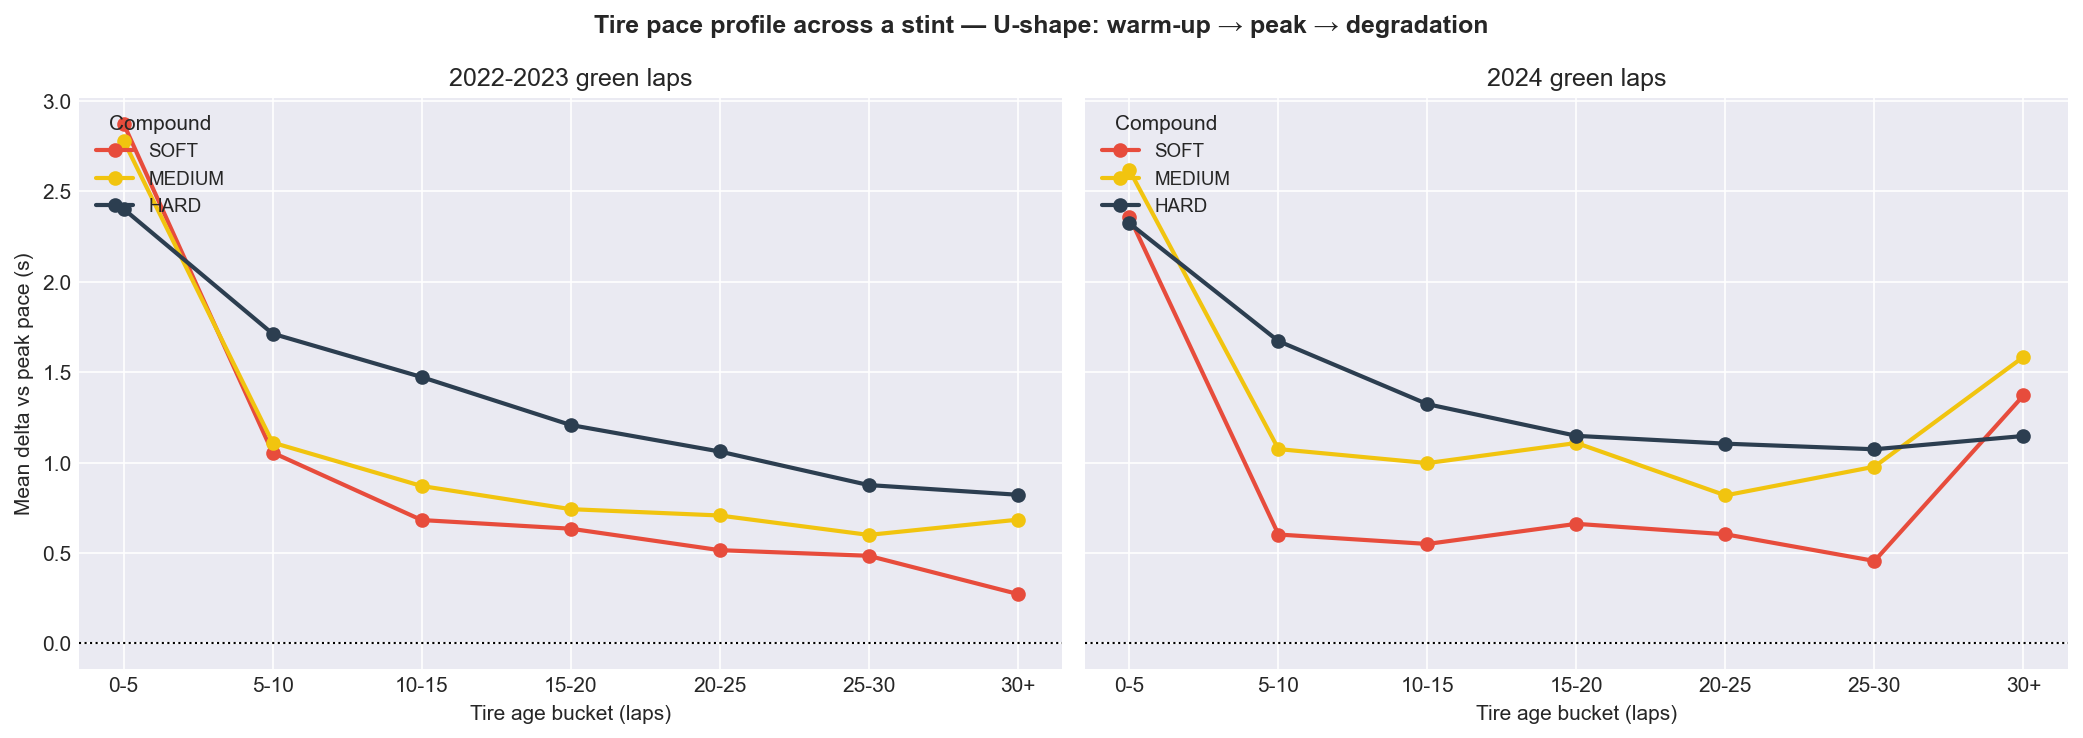

In [2]:
from IPython.display import Image, display

FIGURES_DIR = ROOT / 'outputs' / 'figures'
display(Image(str(FIGURES_DIR / 'degradation_pace_profile.png')))

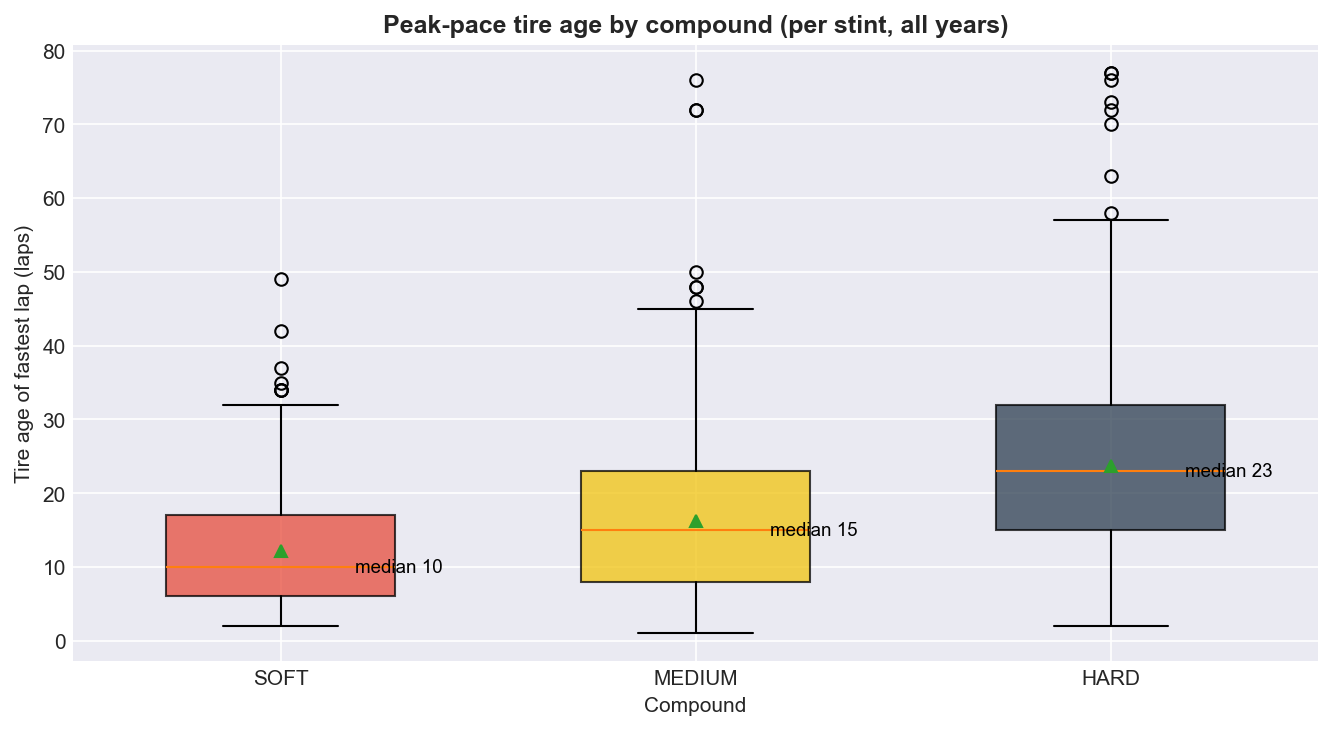

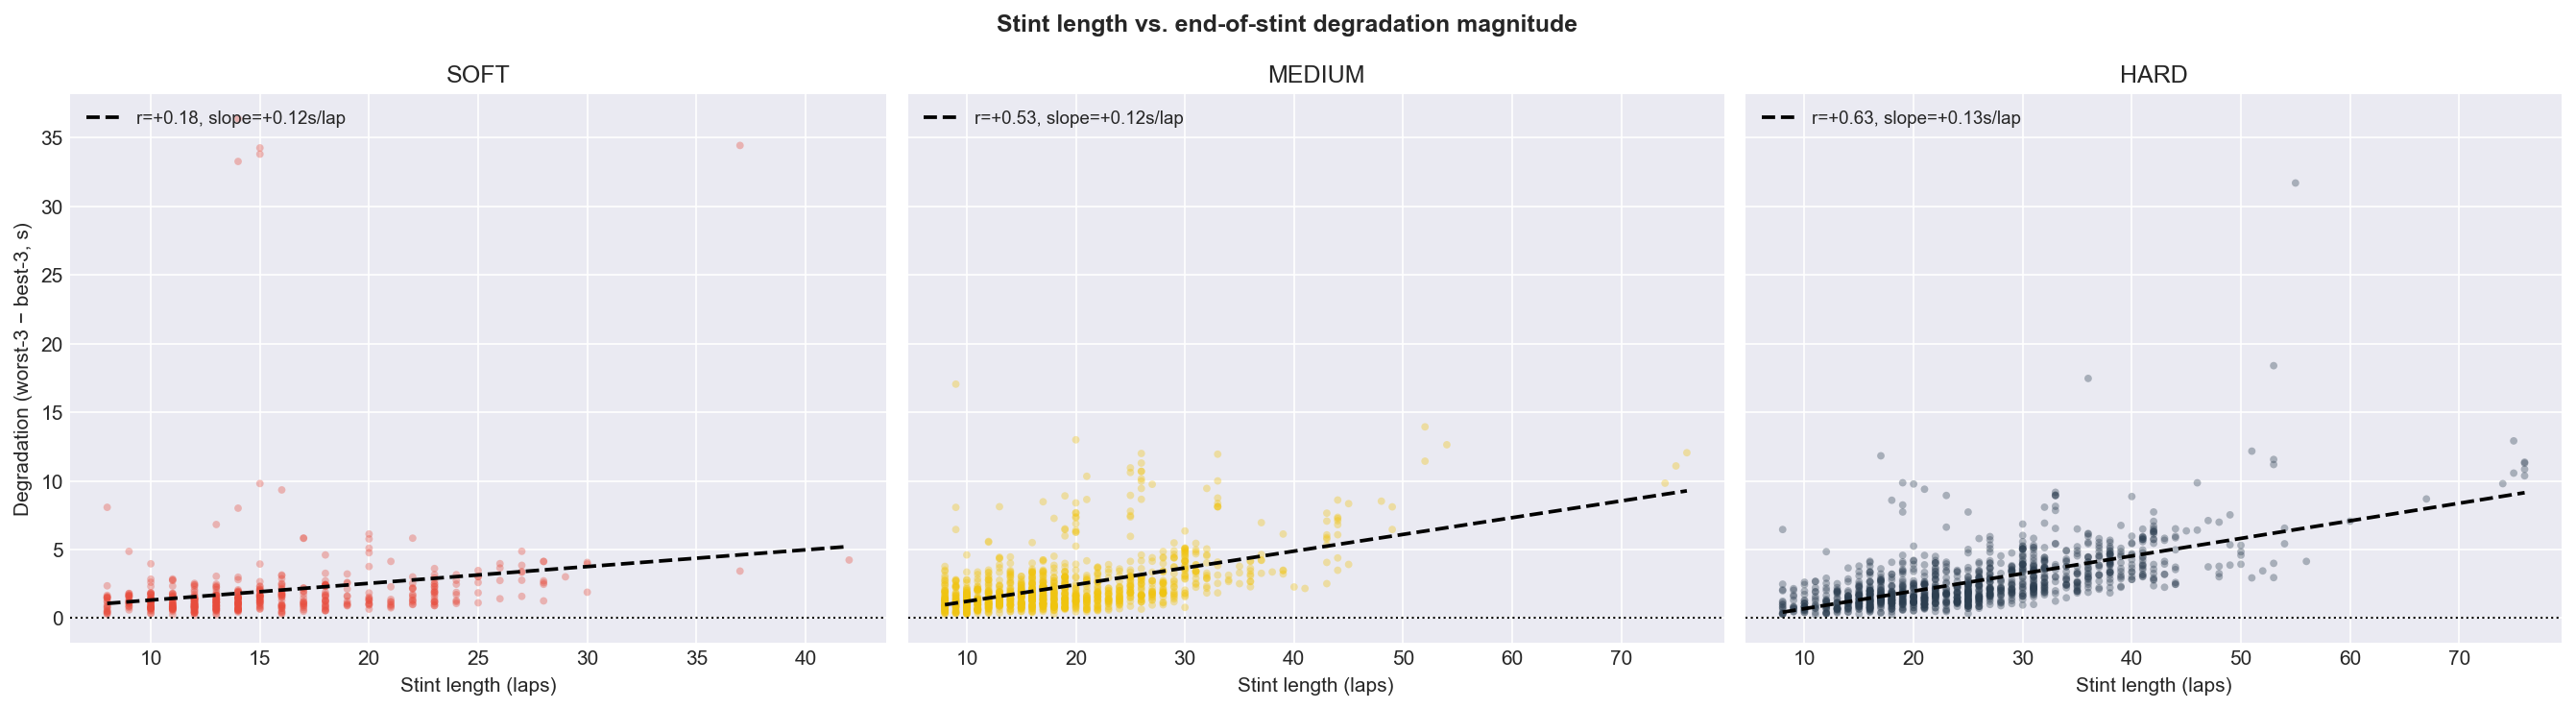

In [3]:
display(Image(str(FIGURES_DIR / 'peak_age_by_compound.png')))
display(Image(str(FIGURES_DIR / 'stint_length_vs_degradation.png')))

**Findings.**

1. **Pace across a stint is U-shaped, not monotonic.** Every compound starts with a warm-up phase of about 0.5 to 2.5 seconds per lap in the first few laps, settles near peak grip, and then starts giving time back as the tire wears out. So the simple story of “new tire fast, old tire slow” is not really true. A lap-1 tire can be about as slow as a much older tire if it has not come in yet.

2. **Peak-pace tire age is a strong compound signature.** Median peak age lands around 10 laps on SOFT, 15 on MEDIUM, and 22 on HARD, and that ordering stays stable across the 2022 to 2023 training era and the 2024 holdout.

3. **Longer stints clearly line up with more degradation on the harder compounds.** Per-stint degradation rises by about 0.12 seconds for every extra lap of stint length, with Pearson correlations of 0.63 on HARD, 0.53 on MEDIUM, and 0.18 on SOFT. Essentially, SOFT stints are too short and too compressed for the same relationship to stand out as clearly.

4. **We intentionally did not force this into a per-lap predictor.** Earlier versions tried a quadratic predictor for `(compound, circuit)` combinations. On the 2024 holdout, that did worse than the simple live slope estimate. So instead of keeping a weaker predictor, we kept the descriptive view because it preserves the real tire-shape story better.


## 5.2 Weather & Temperature Effects on Lap Time

**Question:** how do track temperature, air temperature, and related weather variables line up with lap pace in a small cross-season race sample?

**Setup:** Following notebook `06`, we loaded five races from 2024 and 2025, Bahrain, Saudi Arabia, Australia, Japan, and China. Then we merged session weather observations onto lap data by timestamp and fit a baseline OLS regression of `LapTime_Seconds` on `C(Year) + C(Race) + C(Compound) + TrackTemp + AirTemp + Pressure + Humidity + WindSpeed + WindDirection`, with HC2 robust standard errors. To keep the milestone notebook light, all of the data pull, merge, regression, and figure generation happen in `scripts/build_weather_analysis.py`, and this section just loads the saved outputs.


In [4]:
import joblib
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

ROOT = Path.cwd() if Path.cwd().name != 'notebooks' else Path.cwd().parent
DATA_DIR = ROOT / 'data'
MODEL_DIR = ROOT / 'models'
FIGURES_DIR = ROOT / 'outputs' / 'figures'

weather_df = pd.read_csv(DATA_DIR / 'f1_weather_dataset.csv')
weather_art = joblib.load(MODEL_DIR / 'f1_weather_analysis.pkl')
coef_df = pd.read_csv(DATA_DIR / 'f1_weather_coefficients.csv')

print(f"Merged lap-weather rows: {weather_art['n_rows']:,}")
print(f"Model R-squared: {weather_art['r_squared']:.3f}")
print('\nSelected coefficients:')
print(coef_df[['term', 'coef', 'p_value']].to_string(index=False))


Merged lap-weather rows: 9,836
Model R-squared: 0.309

Selected coefficients:
                       term      coef  p_value
              C(Year)[2024] 5460.4943   0.0000
              C(Year)[2025] 5441.5852   0.0000
         C(Race)[T.Bahrain]   -1.2011   0.3483
           C(Race)[T.China]  -12.8259   0.0000
           C(Race)[T.Japan]  -23.3790   0.0000
    C(Race)[T.Saudi Arabia]    5.0734   0.0000
C(Compound)[T.INTERMEDIATE]   -6.8550   0.0000
      C(Compound)[T.MEDIUM]    0.2819   0.1980
        C(Compound)[T.SOFT]    0.5511   0.1207
                  TrackTemp    0.5508   0.0000
                    AirTemp   -3.7675   0.0000
                   Pressure   -5.1846   0.0000
                   Humidity   -0.6562   0.0000
                  WindSpeed    0.6877   0.0004
              WindDirection    0.0037   0.0006


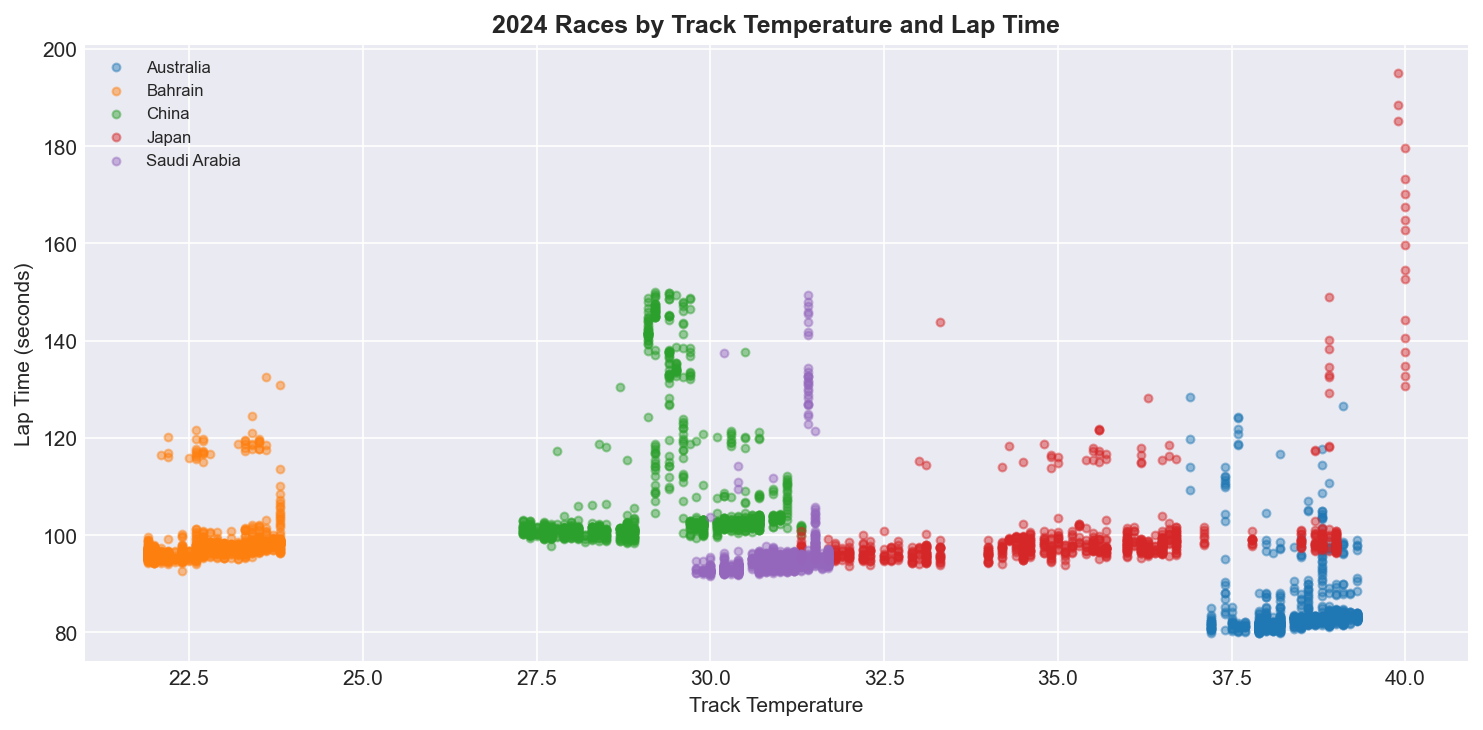

In [5]:
display(Image(str(FIGURES_DIR / 'weather_laptime_scatter.png')))


**Findings.**

1. **Track temperature is significant in the lighter notebook `06` setup.** In the saved baseline OLS, `TrackTemp` has a positive coefficient of **0.551** with a near-zero p-value. In this merged sample, hotter track conditions line up with slower raw race laps.

2. **Other weather terms move with it.** `AirTemp`, `Pressure`, `Humidity`, `WindSpeed`, and `WindDirection` also come in as significant in the fitted model. So we read this section as a descriptive weather-and-lap-time relationship, not as a clean isolated estimate of one variable.

3. **Compound effects are limited in this simpler version.** In the saved coefficient table, `MEDIUM` and `SOFT` are not significant relative to the reference level, while `INTERMEDIATE` is. That says more about the composition of the merged sample than about a pure dry-tire ranking.

4. **This section is intentionally the lighter weather workflow.** We chose to keep the final notebook aligned with notebook `06` instead of carrying over the older, more elaborate interaction-and-diagnostics version.


## 5.3 Pit-Window Forecasting, Gradient Boosted Regressor

**Question:** given the current race state, how many laps are left until a driver’s pit window opens?

**Setup:** This section uses 46,976 lap-level observations from 2022 to 2024, with the target `laps_until_open` bounded to a 20-lap horizon. We used a tuned `GradientBoostingRegressor` with `learning_rate=0.03`, `max_depth=6`, and `n_estimators=200`. If you want the full exploratory work, per-context plots, and feature-importance breakdowns, that is all in `02_pit_window_forecasting.ipynb`.

**Headline results on the 2024 holdout:**

| Metric | Value |
|---|---|
| N (2024 obs) | 15,619 |
| MAE | **2.26 laps** |
| RMSE | 3.48 laps |
| Within ±1 lap | 47.6% |
| Within ±2 laps | 57.5% |
| Within ±5 laps | 84.4% |

**Dominant feature:** `closing_rate` accounts for 63% of total feature importance. So the strongest signal in the whole model is the rate at which the threat car behind is closing the gap. Per-context MAE also shows the model works best in `tight_behind` and worst in `tight_ahead`, which makes sense because traffic ahead depends more on the other car’s choice than on clean observable state.


## 5.4 Pit Strategy: Undercut vs Overcut

**Question:** when two cars are close enough for strategy to matter, which direction wins, pitting now to undercut the car ahead, or staying out to overcut the car that just pitted?

**Setup.** We trained both directions on 2022 to 2023 race data and evaluated them on a 2024 temporal holdout. Each direction uses a Logistic Regression baseline plus an XGBoost primary model. The feature sets are nearly the same, but the tire-age framing changes depending on whether we are talking about the undercut or the overcut.

**Feature parity.**

| Concept | Undercut feature | Overcut feature |
|---|---|---|
| Relative tire age | `tire_age_advantage = ca_age − driver_age` (positive is good for pitter) | `tire_age_delta = stay_out_age − ca_age` (positive is bad for stay-out) |
| Gap | `gap_ahead` (pitter to target) | `gap_ahead` (stay-out to target) |
| Pace differential | `pace_delta = own_pace − threat_pace` | Same, reversed framing |
| In-stint deg slope | `deg_delta`, `ca_deg_delta` | Same |
| Closing rate | `closing_rate` | Same |
| Race context | `pit_loss`, `pit_loss_fraction`, `race_progress`, one-hot `compound` | Same |

**Headline results (2024 holdout).**

| Strategy | Model | Accuracy | ROC-AUC | F1 | Base rate |
|---|---|---|---|---|---|
| Undercut | Logistic Regression | 0.771 | 0.825 | N/A | 0.441 |
| Undercut | XGBoost (primary) | 0.738 | 0.806 | N/A | 0.441 |
| Overcut  | Logistic Regression | 0.823 | 0.807 | 0.46 | 0.251 |
| Overcut  | XGBoost (primary) | 0.805 | 0.804 | 0.56 | 0.251 |

**Combined SHAP takeaway.** The two directions are not driven by exactly the same thing. Under the undercut framing, `tire_age_advantage` dominates. That fits the real mechanism, where the fresh-tire gain after the stop has to overcome the car ahead on older rubber. For the overcut, the strongest SHAP drivers are `pace_delta` and the size of `tire_age_delta`. In other words, the stay-out car has to keep running genuinely strong laps even before its own stop.

**Asymmetry.** Overcuts are much harder than undercuts in this sample. The base success rate is 25.1% for overcuts versus 44.1% for undercuts. That is why the nonlinear model helps more on the overcut side. The full pipelines, EDA, and SHAP plots are in `03_undercut_prediction.ipynb` and `04_overcut_prediction.ipynb`.


## 5.5 Race Position Prediction, Simple 2024 vs 2025 Comparison

**Question:** if we only use a simple race-state snapshot, how does finishing-bucket predictability grow through the race, and how does that compare between 2024 and 2025?

**Setup:** Following notebook `05`, we evaluate a lightweight `RandomForestClassifier` at lap checkpoints `{5, 10, 20, 30, 40, 50}` on a fixed race subset of Bahrain, Saudi Arabia, Australia, Japan, and Miami. At each checkpoint, the model only uses current position, tire compound, and tire life to predict a 4-bucket final finishing class: Podium, Top Points, Low Points, or Out of Points. We kept this section intentionally simple, and the milestone notebook just loads the saved outputs produced by `scripts/build_position_comparison_analysis.py`.


In [6]:
import joblib
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

ROOT = Path.cwd() if Path.cwd().name != 'notebooks' else Path.cwd().parent
DATA_DIR = ROOT / 'data'
MODEL_DIR = ROOT / 'models'
FIGURES_DIR = ROOT / 'outputs' / 'figures'

curve = pd.read_csv(DATA_DIR / 'f1_position_comparison_curve.csv')
pos_art = joblib.load(MODEL_DIR / 'f1_position_comparison_analysis.pkl')

print('Predictability curve — simple snapshot model by season and checkpoint lap:')
print(curve.pivot(index='checkpoint_lap', columns='year', values='accuracy').round(3).to_string())


Predictability curve — simple snapshot model by season and checkpoint lap:
year             2024   2025
checkpoint_lap              
5               0.526  0.467
10              0.526  0.467
20              0.500  0.467
30              0.833  0.667
40              0.833  0.889
50              1.000  0.882


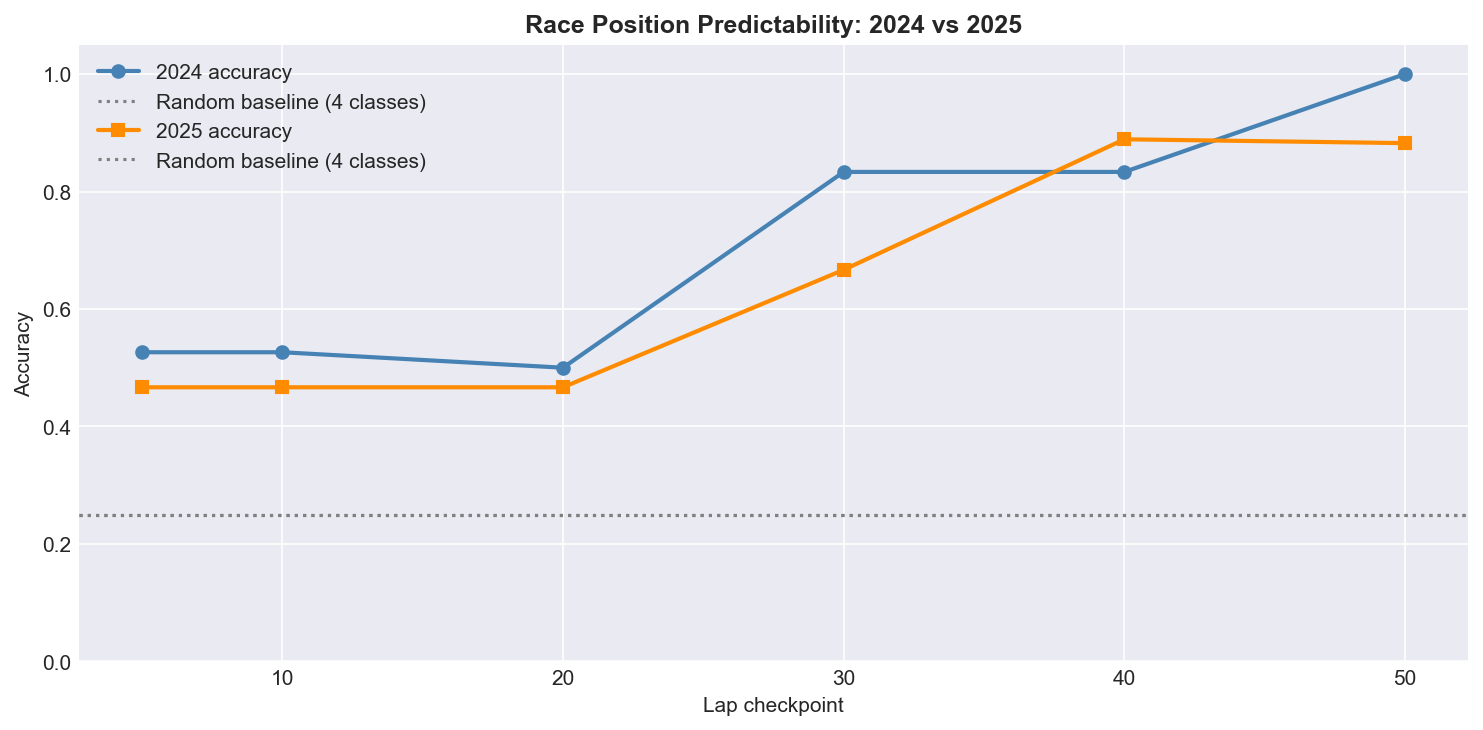

In [7]:
display(Image(str(FIGURES_DIR / 'position_comparison_curve.png')))


In [8]:
curve_2024 = curve[curve['year'] == 2024].dropna(subset=['accuracy'])
curve_2025 = curve[curve['year'] == 2025].dropna(subset=['accuracy'])
print('Best observed checkpoint by season:')
for year, sub in [(2024, curve_2024), (2025, curve_2025)]:
    if sub.empty:
        continue
    best = sub.sort_values('accuracy', ascending=False).iloc[0]
    print(f"  {year}: lap {int(best['checkpoint_lap'])} -> accuracy {best['accuracy']:.3f}")


Best observed checkpoint by season:
  2024: lap 50 -> accuracy 1.000
  2025: lap 40 -> accuracy 0.889


In [9]:
print('Race subset used:')
print(', '.join(pos_art['races']))


Race subset used:
Bahrain, Saudi Arabia, Australia, Japan, Miami


**Findings.**

1. **The simple snapshot becomes much more informative later in the race.** On the fixed race subset, 2024 accuracy rises from **52.6% at lap 5** to **100.0% at lap 50**, while 2025 rises from **46.7% at lap 5** to **88.2% at lap 50**.

2. **The major jump happens around lap 30.** The 2024 line moves from **50.0% at lap 20** to **83.3% at lap 30**, and the 2025 line moves from **46.7%** to **66.7%** over the same interval, which is consistent with race order becoming easier to call once pit sequences begin to resolve.

3. **This is intentionally a minimal-feature comparison.** Because the model uses only current position, tyre compound, and tyre life, the resulting curve should be interpreted as the predictive value of a simple race-state snapshot rather than as the strongest position model in the codebase.

4. **This section now directly reflects notebook `05`.** The final report intentionally adopts that notebook's lighter checkpoint-comparison framing rather than the heavier script-backed random-forest pipeline that was previously summarized here.


## 5.6 Integrated Race-Day Example, 2024 Hungarian Grand Prix

To show how the project fits together as one strategy workflow, we run the unchanged `5.3` and `5.4` models on **2024 Hungary**. We picked Hungary because overtaking is difficult there, so pit-window timing and stop decisions really matter. For one driver, we plot:

- the **pit-window forecast** across the race
- the **undercut success probability** on the laps where that driver actually pitted to try it
- the **overcut success probability** on the laps where that driver stayed out while the car ahead pitted first

So this section is meant to show the race-day strategy view. The lighter `5.5` position comparison stays separate, while the dashboard here focuses only on the pit-window and strategy models.


In [10]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

ROOT      = Path.cwd() if Path.cwd().name != 'notebooks' else Path.cwd().parent
DATA_DIR  = ROOT / 'data'
MODEL_DIR = ROOT / 'models'

RACE_YEAR = 2024
RACE_NAME = 'Hungarian Grand Prix'
DRIVER    = 'LEC'  # Chosen because Hungary provides both undercut and overcut decisions

# ── Pit-window forecast inputs ─────────────────────────────────────────────
pw_df    = pd.read_csv(DATA_DIR / 'f1_pit_window_labels.csv')
pw_art   = joblib.load(MODEL_DIR / 'f1_pit_window_model_tuned.pkl')
pw_model = pw_art['model']
pw_encs  = pw_art['encoders']

pw_driver = pw_df[(pw_df['year'] == RACE_YEAR) &
                  (pw_df['circuit'] == RACE_NAME) &
                  (pw_df['driver'] == DRIVER)].copy()
pw_driver['context_str'] = pw_driver['context'].astype(str)
pw_driver['compound_str'] = pw_driver['compound'].astype(str)
pw_driver['context'] = pw_encs['context'].transform(pw_driver['context_str'])
pw_driver['compound'] = pw_encs['compound'].transform(pw_driver['compound_str'])
feat_cols_pw = list(pw_model.feature_names_in_)
num_feats = [c for c in feat_cols_pw if c not in ('context', 'compound')]
for col in num_feats:
    pw_driver[col] = pd.to_numeric(pw_driver[col], errors='coerce')
    pw_driver[col] = pw_driver[col].fillna(pd.to_numeric(pw_df[col], errors='coerce').median())
pw_driver['predicted_laps_until_open'] = pw_model.predict(pw_driver[feat_cols_pw].values.astype(float))

# ── Undercut decision probabilities ────────────────────────────────────────
undercut_art = joblib.load(MODEL_DIR / 'f1_undercut_model.pkl')
undercut_model = undercut_art['model']
undercut_features = undercut_art['features']
undercut_df = pd.read_csv(DATA_DIR / 'f1_undercut_dataset.csv')
undercut_dummies = pd.get_dummies(undercut_df['compound'], prefix='compound')
undercut_feat = pd.concat([undercut_df, undercut_dummies], axis=1)
for col in undercut_features:
    if col not in undercut_feat.columns:
        undercut_feat[col] = 0
for col in undercut_features:
    undercut_feat[col] = pd.to_numeric(undercut_feat[col], errors='coerce')
    undercut_feat[col] = undercut_feat[col].fillna(undercut_feat[col].median())
undercut_driver = undercut_feat[(undercut_feat['year'] == RACE_YEAR) &
                              (undercut_feat['circuit'] == RACE_NAME) &
                              (undercut_feat['driver'] == DRIVER)].copy()
if not undercut_driver.empty:
    undercut_driver['prob_success'] = undercut_model.predict_proba(
        undercut_driver[undercut_features].values.astype(float)
    )[:, 1]

# ── Overcut decision probabilities ─────────────────────────────────────────
overcut_art = joblib.load(MODEL_DIR / 'f1_overcut_model.pkl')
overcut_model = overcut_art['model']
overcut_features = overcut_art['features']
overcut_df = pd.read_csv(DATA_DIR / 'f1_overcut_dataset.csv')
overcut_dummies = pd.get_dummies(overcut_df['compound'], prefix='compound')
overcut_feat = pd.concat([overcut_df, overcut_dummies], axis=1)
for col in overcut_features:
    if col not in overcut_feat.columns:
        overcut_feat[col] = 0
for col in overcut_features:
    overcut_feat[col] = pd.to_numeric(overcut_feat[col], errors='coerce')
    overcut_feat[col] = overcut_feat[col].fillna(overcut_feat[col].median())
overcut_driver = overcut_feat[(overcut_feat['year'] == RACE_YEAR) &
                            (overcut_feat['circuit'] == RACE_NAME) &
                            (overcut_feat['stay_out_driver'] == DRIVER)].copy()
if not overcut_driver.empty:
    overcut_driver['prob_success'] = overcut_model.predict_proba(
        overcut_driver[overcut_features].values.astype(float)
    )[:, 1]

print(f'Driver {DRIVER} @ {RACE_YEAR} {RACE_NAME}')
print(f'  pit-window rows:   {len(pw_driver)}')
print(f'  undercut events:   {len(undercut_driver)}')
print(f'  overcut events:    {len(overcut_driver)}')
if not undercut_driver.empty:
    print('\nUndercut decisions:')
    print(undercut_driver[['pit_lap', 'car_ahead', 'gap_ahead', 'prob_success', 'undercut_success']].round(3).to_string(index=False))
if not overcut_driver.empty:
    print('\nOvercut decisions:')
    print(overcut_driver[['pit_lap', 'pitting_car', 'stay_out_laps', 'gap_ahead', 'prob_success', 'overcut_success']].round(3).to_string(index=False))


Driver LEC @ 2024 Hungarian Grand Prix
  pit-window rows:   50
  undercut events:   1
  overcut events:    2

Undercut decisions:
 pit_lap car_ahead  gap_ahead  prob_success  undercut_success
      40       VER      1.307         0.742                 1

Overcut decisions:
 pit_lap pitting_car  stay_out_laps  gap_ahead  prob_success  overcut_success
      16         HAM              7      1.735         0.017                0
      21         VER              2      3.568         0.027                0


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


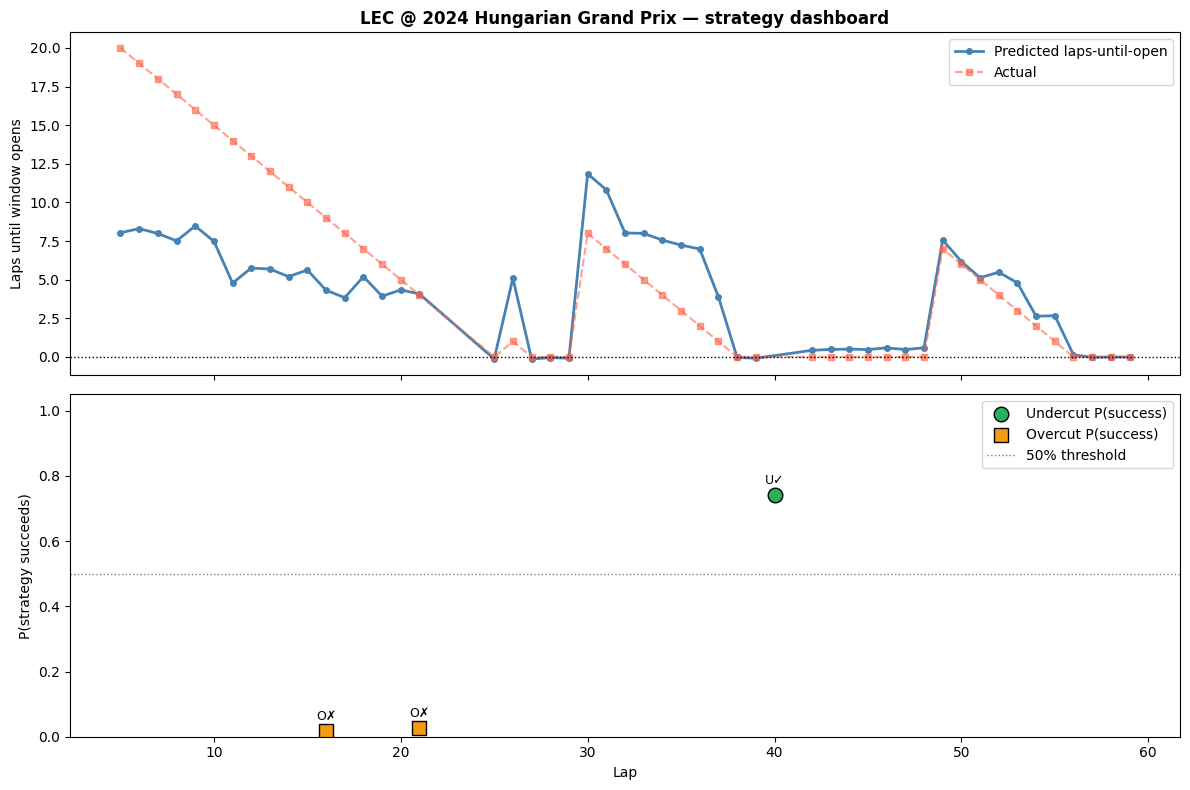

In [11]:
# ── Plot integrated strategy dashboard ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: pit-window forecast vs actual
axes[0].plot(pw_driver['lap'], pw_driver['predicted_laps_until_open'],
             'o-', color='steelblue', label='Predicted laps-until-open',
             linewidth=2, markersize=4)
axes[0].plot(pw_driver['lap'], pw_driver['laps_until_open'],
             's--', color='tomato', label='Actual', alpha=0.6, markersize=4)
axes[0].set_ylabel('Laps until window opens')
axes[0].set_title(f'{DRIVER} @ {RACE_YEAR} {RACE_NAME} — strategy dashboard', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].axhline(0, color='black', linestyle=':', linewidth=1)

# Bottom: undercut / overcut probabilities at real decision points
if not undercut_driver.empty:
    axes[1].scatter(undercut_driver['pit_lap'], undercut_driver['prob_success'],
                    s=110, color='#27ae60', edgecolor='black', label='Undercut P(success)')
    for _, row in undercut_driver.iterrows():
        label = 'U✓' if int(row['undercut_success']) == 1 else 'U✗'
        axes[1].annotate(label, (row['pit_lap'], row['prob_success']),
                         textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

if not overcut_driver.empty:
    axes[1].scatter(overcut_driver['pit_lap'], overcut_driver['prob_success'],
                    s=110, color='#f39c12', marker='s', edgecolor='black',
                    label='Overcut P(success)')
    for _, row in overcut_driver.iterrows():
        label = 'O✓' if int(row['overcut_success']) == 1 else 'O✗'
        axes[1].annotate(label, (row['pit_lap'], row['prob_success']),
                         textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

axes[1].axhline(0.5, color='grey', linestyle=':', linewidth=1, label='50% threshold')
axes[1].set_xlabel('Lap')
axes[1].set_ylabel('P(strategy succeeds)')
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='upper right')

plt.tight_layout()
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / 'integrated_race_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


**Reading the dashboard.** In the top panel, we compare the pit-window model’s prediction to the actual opening of the window for Charles Leclerc in the Hungarian Grand Prix. When the blue and red lines stay close, the model is tracking the strategy situation well. When they separate more, it usually happens in the traffic-heavy parts of the race, which fits what we saw in the `5.3` context breakdown.

In the bottom panel, each marker is a real undercut or overcut decision point from `5.4`. The marker position tells us when the decision happened and how likely the model thought it was to work. The labels `U✓`, `U✗`, `O✓`, and `O✗` show whether it actually did. Essentially, this is the integrated strategy picture we wanted, one continuous pit-window forecast plus discrete pit-stop decision probabilities.


## 6. Peer Feedback

**Feedback group:** Joely Marsyla, Caitlin Roake, Natalie Zorn

---

We got useful feedback during the in-class milestone presentation. A lot of it helped us sharpen how the project was framed, especially around evaluation and how the five questions connect.

### 6.1 Feedback Received

**Strength, Strong domain grounding and clear motivation**
> The group noted that the project was well motivated and felt closely tied to how real F1 strategy teams think. They specifically pointed out details like the fuel correction and circuit-specific pit loss as things that made the project feel more grounded than a generic sports analytics idea.

**Concern, Model evaluation and train-test split clarity**
> Reviewers pointed out that the preliminary race-position classifier had been trained and evaluated on the same dataset, which made the reported accuracy hard to trust. They suggested a proper temporal holdout, such as training on 2022 to 2023 and testing on 2024.

**Suggestion, Clarify scope across the five research questions**
> The group suggested being more explicit about how the questions connect, especially which models feed into others and which ones are most central to the project.

**Question, How are lapped cars handled in gap calculations?**
> Natalie asked an important technical question about whether lapped cars could distort `GapAhead` and `GapBehind`. That was a valid concern, and we addressed it by using a same-lap filter in the gap logic.

---

### 6.2 Our Response and Planned Adjustments

| Feedback | Action Taken / Planned |
|----------|----------------------|
| Overfitting risk in position classifier | We replaced the older report-facing version with the simpler `5.5` checkpoint comparison and made the methodology explicit. |
| Scope clarification across 5 questions | We kept the notebook ordered from lower-level physical signals to higher-level strategic outcomes, and we used `5.6` to tie the strategy models together. |
| Lapped car gap contamination | Already handled through same-lap filtering in the gap-computation workflow. |
| Model interpretability | Kept SHAP and feature-importance analysis in the strategy notebooks so the main claims stay explainable. |


## 7. Process Summary & Completed Milestones

At this point, every proposal milestone is complete. Here is the final state of the project.

**Data & pipeline**
- [x] FastF1 integration and local caching for 2020 to 2024
- [x] Lap-quality filtering, pit-lap and out-lap exclusion, and SC/VSC masking
- [x] Inter-car gap computation using LapStartTime ordering
- [x] Context classifier with `tight_ahead`, `tight_behind`, `tight_both`, and `free`
- [x] Fuel correction using 1.8 kg per lap and 0.035 s per kg
- [x] Per-stint baseline and delta-pace computation feeding `5.1`
- [x] Circuit pit-loss computation from real pit-in and pit-out deltas
- [x] Timestamp-based lap-weather merge for the fixed 2024 to 2025 weather sample used in `5.2`

**Models / analyses**
- [x] Tire degradation stint-level analysis with peak-pace anchor, pace profile, peak-age by compound, and stint-length versus degradation correlation, using `scripts/build_degradation_dataset.py`
- [x] Weather baseline OLS on merged lap-weather data, with a saved coefficient table and scatter figure, using `scripts/build_weather_analysis.py`
- [x] Pit-window Gradient Boosted Regressor with MAE 2.26 laps on the 2024 holdout, documented in `02_pit_window_forecasting.ipynb`
- [x] Undercut Logistic Regression plus XGBoost, with 77% accuracy and ROC-AUC 0.83, documented in `03_undercut_prediction.ipynb` and `scripts/build_undercut_dataset.py`
- [x] Overcut Logistic Regression plus XGBoost, with 81% accuracy and ROC-AUC 0.80, documented in `04_overcut_prediction.ipynb` and `scripts/build_overcut_dataset.py`
- [x] Simplified 2024 vs 2025 race-position checkpoint comparison based on current position, tire compound, and tire life, using `scripts/build_position_comparison_analysis.py`

**Analysis & visualization**
- [x] Three tire-degradation figures for `5.1`
- [x] Weather coefficient table and track-temperature scatter for `5.2`
- [x] SHAP attribution for both undercut and overcut models
- [x] Probability calibration plots for both strategy models
- [x] Per-context and per-race-quarter MAE breakdowns for the pit-window model
- [x] Simplified 2024 vs 2025 position-comparison curve for `5.5`
- [x] Integrated Hungary strategy dashboard for `5.6`
- [x] Interactive test harnesses for browsing undercut and overcut predictions

**Peer-feedback response:** The most important issue raised by peers was the earlier position-model evaluation problem. We addressed that by making the final report’s `5.5` section explicitly lighter, narrower, and honest about what it measures.


## 8. Limitations

Every model here is trained on **public timing data only**, so there are some limits we cannot really get around.

**1. Weather and track evolution.** The `5.2` weather model is intentionally lightweight. It regresses raw lap time on merged weather covariates across a small race sample, so it should be read as descriptive rather than as a clean causal estimate of temperature. The same goes for the simplified `5.5` position comparison, which leaves out richer race-state features like live gaps and rolling pace.

**2. Safety Car and red-flag events.** We filter SC and VSC contamination out of training where we can, but the models obviously do not know when a neutralization is about to happen. If a Safety Car appears during a strategy decision, the real race can move in a direction the model could not have predicted.

**3. Driver-level effects.** We mostly treat drivers as interchangeable. That means we are not directly modeling driver-specific stint management, tire saving, or pit-stop execution style.

**4. Team strategy and radio.** The models do not know about team orders, tire-allocation constraints, or internal team priorities. So two situations that look similar in the timing data may still lead to different decisions in the real race.

**5. Tire degradation analysis simplifications.** `5.1` is descriptive by design. It gives us the pace profile, peak age, and stint-length relationship, but it does not produce a high-quality per-lap predictor of degradation. We tested that idea and dropped it because it did not hold up well enough on the holdout.

**6. Finite sample size in the lighter report-facing sections.** The weather and position sections use smaller fixed race subsets so the final notebook stays lightweight and directly tied to notebooks `06` and `05`. That makes them easier to reproduce, but it also makes them more sensitive to race selection.

**7. Regulation-era dependence.** All of this is built on the 2022 to 2025 ground-effect era. If the regulations change substantially, the models would need to be retrained.


## 9. Conclusions

Across the five questions, the project produced a pretty clear picture of what public F1 timing data can and cannot tell us.

**1. Tire degradation.** Lap pace across a stint is not monotonic. It is U-shaped. Tires warm up, hit peak grip, and then degrade. Peak-pace age also separates cleanly by compound, around 10 laps for SOFT, 15 for MEDIUM, and 22 for HARD.

**2. Weather and temperature.** In the lighter notebook `06` setup now used in `5.2`, track temperature stays statistically significant, with a positive coefficient of about 0.55 seconds per degree in the merged sample. But we still treat that as a descriptive relationship, not a clean causal claim.

**3. Pit-window forecasting.** The tuned Gradient Boosted Regressor predicts the opening lap within ±2 laps for 57.5% of observations and within ±5 laps for 84.4% on the 2024 holdout. The biggest takeaway is that `closing_rate` dominates the model. So pit windows are really about dynamic pressure, not just a static gap.

**4. Undercut versus overcut.** Both strategy directions contain real predictive signal, with ROC-AUC around 0.80. But they are not mirror images. The undercut is driven more by tire-age advantage, while the overcut depends more heavily on pace in clean air. Overcuts are also just harder in general, with a much lower base success rate.

**5. Race predictability.** In the lighter notebook `05` framing used for `5.5`, even a minimal snapshot of position, compound, and tire life gets much more informative after the midpoint of the race. The biggest jump happens around lap 30, and by lap 40 to 50 the simple classifier is already doing quite well.

**What I think matters most here:** the strongest part of the project is that the sections fit together. The tire work helps explain the pit-window problem. The pit-window and strategy models then feed naturally into the race-day view. So the main takeaway is not just that one model worked well. It is that public F1 timing data is rich enough to support a realistic and explainable strategy framework.

**Future work.** The clearest next steps would be making the weather section more controlled, adding more driver-specific information into the strategy models, and reducing duplicated logic between the undercut and overcut pipelines.
